In [1]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt

Our contributions for each part of the assignment are denoted by our initials.

# Designing the Threat Index (Winter Weather Impacts on Energy Demand) (MP and PD)
- We will look at two main impacts on energy demand caused by winter weather which are power outages and overall increased demand for heating due to colder weather
- Increased ice and snow accumulation can cause excess weight on power lines, trees, and branches which can cause these tress to fall onto power lines or these power lines to fall themselves
- Wind gusts can also increase the chance of branches and power lines collapsing
- With power being out, demand for electricity is still needed and not available, further increasing energy demand
- On the other hand, extreme cold will highly increase the demand of in home heating needed, increasing the demand for energy
- This can lead to potential shortages and high costs
## Target Audience
- Our target audience can be the general public to see when energy prices will increase
- Another audience can be utility and energy companies to account for extra demand during these times of winter weather
## Scale/Range
- We will make the range from 0-10 with 0 being no impacts on the demand of energy based on winter weather impacts and 10 being extreme impacts
- This is an easy to read scale while also being somewhat precise with allowing for decimal place accuracy
## Variables Used
- The variables we will be using are precipitation type, precipitation rate, 10m wind gust, wind chill, and 2m temperature
## Weighting of variables
- P-type: 27.5%
- P-rate: 2.5%
- 10m wind gust: 27.5%
- Wind Chill: 27.5%
- 2m Temperature: 15%
- We chose to weight p-type and 10m wind gust high due to potential effects of power outages being higher based on snow/wet snow and strong wind gusts being impactful for power outages
- Wind chill is also weighted highly because this is the temperature that people are feeling outside, causing them to increase heating in their homes if this is low
- 2m temperature and p-rate are weighted slightly lower because 2m temperature is not exactly what the public is feeling, but still impactful for precipitaton type. Precipitation rate is impactful to see how much precipitation can fall in a ceratain amount of time, but not as impactful as the type of precipitation. For example, if there is a strong rate of rain, it will not have much impact on power lines.
### Lowest possible values
- No precipitation, 2m > 40F, wind chill > 40F, 10m wind gust < 10kt
### Highest possible values
- Snow, wet snow, and ice will be the "worst" precipitation types, p-rate > 1 in/hr, wind chill < 0 F, 2m temp < 10F, 10m wind gust > 35 kt

# Calculation of Variables (MP)

In [2]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
ds_test = xr.open_dataset("ecmwf_update5.nc").load()
ds_test

sh: 1: getfattr: not found


<xarray.Dataset> Size: 182MB
Dimensions:            (valid_time: 17, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB 256.7 .....
    fg10               (valid_time, latitude, longitude) float32 3MB 0.0 ... nan
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    tp                 (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sd                 (valid_time, latitude, longitude) float32 3MB 0.1411 ....
    ptype              (valid_time, latitude, longitude) float32 3MB 0.0 ... 1.0
    tprate             (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sp                 (valid_time, latitude, longitude) float32 3MB 8.972e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T14:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# grabbing time index from previous milestone
time_index = 11
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

# Wind Chill Index (MP)

In [5]:
# Wind chill index (using code to define wind chill from previous milestone), changed to 10m wind gust
# deriving wind whill
#u_wind = ds_test['u'].isel(isobaricInhPa=0).isel(valid_time=time_index)
#v_wind = ds_test['v'].isel(isobaricInhPa=0).isel(valid_time=time_index)
wind_gust = ds_test['fg10'].isel(valid_time=time_index).values
t2m = ds_test['t2m'].isel(valid_time=time_index).values

# converting t2m to F
t2m_F = (t2m - 273.15) * 9/5 + 32
# calculating total wind
#V_ms = np.sqrt(u_wind**2 + v_wind**2)
V_mph = wind_gust * 2.237
# applying WC formula
wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
# masking invalid conditions 
wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, t2m_F)
#wind_chill = np.nan_to_num(wind_chill, nan=0)

In [6]:
wind_chill

array([[-1.4388018e+00, -6.2737613e+00, -7.4607897e-01, ...,
        -3.2545135e+01, -2.7648439e+01, -2.3644650e+01],
       [ 6.8588257e-03,  3.8183041e+00,  2.4964695e+00, ...,
        -3.6942806e+01, -3.4329613e+01, -2.6688408e+01],
       [-6.2705235e+00, -6.2244611e+00, -5.1147017e+00, ...,
        -3.5687607e+01, -3.5076508e+01, -2.8821356e+01],
       ...,
       [ 6.8836937e+01,  6.8443192e+01,  6.8443192e+01, ...,
         7.5024437e+01,  7.6543190e+01,  7.7105690e+01],
       [ 6.8949440e+01,  6.9230690e+01,  6.9118187e+01, ...,
         7.6036942e+01,  7.5755692e+01,  7.6374435e+01],
       [ 6.9905685e+01,  6.9511940e+01,  6.9230690e+01, ...,
         7.6093185e+01,  7.5755692e+01,  7.6768188e+01]],
      shape=(161, 281), dtype=float32)

In [33]:
def GeoAxes():
    fig = plt.figure(figsize=(15,9))
    ax = plt.axes(projection=ccrs.LambertConformal())
    ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, ax  

In [8]:
def GeoAxes2d():
    fig, axs = plt.subplots(2,3, figsize = (15,9), subplot_kw={"projection":ccrs.LambertConformal()})
    for ax in axs.flatten():
        ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
        ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
        ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, axs

In [9]:
# defining index contributions of wind chill

#WC_contribution = np.zeros_like(wind_chill)
#WC_contribution[mask] = 1.0

#mask = wind_chill > 40
#WC_contribution[mask] = 0

# decrease linearly from 0.5 to 0 from 20F to 40F
#mask = (wind_chill > 20) & (wind_chill <= 40)
#WC_contribution[mask] = 0.5 - (wind_chill[mask] - 20) * (0.5/20)

# decrease linearly from 0.8 to 0.5 from 0F to 20F
#mask = (wind_chill > 0) & (wind_chill <= 20)
#WC_contribution[mask] = 0.8 - wind_chill[mask] * (0.3/20)

# between -10 and 0 with values from 0.8 to 0.9
#mask = (wind_chill < 0) & (wind_chill <=-10)
#WC_contribution[mask] = 0.9 - (wind_chill[mask]+10) * (0.1/10)

#(wind_chill from -20 t0 -10 with values from 0.9 to 1
#mask = (wind_chill > -20) & (wind_chill <= -10)
#WC_contribution[mask] = 1.0 - (wind_chill[mask] + 20) * (0.1/10)

#mask = wind_chill <= -20
#WC_contribution[mask] = 1.0

# Meaning of function (MP)
- Between -20 and -10, values decrease linearly from 1 to 0.9
- Between -10 and zero, values decrease linearly from 0.9 to 0.8
- Between 0 and 20, values decrerase linearly from 0.8 to 0.5
- Between 20 and 40, values decrease linearly from 0.5 to 0
- Was overwriting ranges originally using the example code from MS2, so I used ChatGPT to define a single function to sort through these values

In [10]:

WC_contribution = np.clip(
    1.0
    - 0.1 * np.clip((wind_chill + 20) / 10, 0, 1)   # -20 → -10
    - 0.1 * np.clip((wind_chill + 10) / 10, 0, 1)   # -10 → 0
    - 0.3 * np.clip((wind_chill - 0) / 20, 0, 1)    # 0 → 20
    - 0.5 * np.clip((wind_chill - 20) / 20, 0, 1),  # 20 → 40
    0, 1
)
WC_contribution_f = WC_contribution*10

# Precpitation rate index function (MP)

In [11]:
tprate = ds_test['tprate'].values

In [12]:
tprate_in = tprate*141.73
tprate_in.max()

np.float32(1.3705994)

### Index weighting precip rate (testing)
- Greatest value in data set is 0.88 in/hr, defined above that prate>1 will be the "worst condition". Although it is not present in this dataset, I think we will still use this as the worst condition
- 0-0.1 in/hr lowest contribution 0
- 0.1-0.3 in/hr moderate contribution (0 to 0.2)
- 0.3-0.5 in/hr higher contribution (0.4 to 0.6)
- 0.5-0.8 in/hr very large threat (0.6 to 0.8)
- 0.8-1 in/hr highest threat (0.8 to 1)

In [13]:
tprate_contribution = np.clip(
    0.0
    +0.2 * np.clip((tprate_in - 0.1) / 0.2, 0, 1)
    +0.4 * np.clip((tprate_in - 0.3) / 0.3, 0, 1)
    +0.2 * np.clip((tprate_in - 0.5) / 0.2, 0, 1)
    +0.2 * np.clip((tprate_in - 0.8) / 0.2, 0, 1),
    0, 1
)
tprate_contribution_f = tprate_contribution*10

# Precipitaton type index (MP)

In [14]:
       # 0 = No precipitation
       # 1 = Rain
         # 3 = Freezing rain
       # 5 = Snow
       # 6 = Wet snow
         # 7 = Rain/Snow mix
     # 8 = Ice pellets
        # 12 = Freezing drizzle

## Index values
- Freezing rain has the largest impact
- Wet snow second largest 
- Freezing drizzle, although lighter precipitation it can accumulate better than heavy freezing rain
- Snow fourth largest, but it is much more common and will be weighted similarly to wet snow (5)
- Ice pellets have fifth largest impact
- Rain/snow mix has sixth largest
- Rain has little impact
- No precip has no impact

In [15]:
# Ordered from least → most impactful
ptype = ds_test['ptype'].values
ptype_scale = {
    0: 0,  # None
    1: 1,  # Rain
    7: 2,  # Rain/snow mix
    8: 3,  # Ice pellets
    5: 4,  # Snow
    12: 5, # Freezing drizzle
    6: 6,  # Wet snow
    3: 7   # Freezing rain
}
ptype_rank = np.vectorize(ptype_scale.get)(ptype)

In [16]:
ptype_contribution = np.clip(
    0.0
    + 0.25 * np.clip((ptype_rank - 1) / 2, 0, 1)   # Rain → Mix
    + 0.25 * np.clip((ptype_rank - 3) / 2, 0, 1)   # Ice → Snow
    + 0.25 * np.clip((ptype_rank - 5) / 1, 0, 1)   # FZDZ → Wet snow
    + 0.25 * np.clip((ptype_rank - 6) / 1, 0, 1),  # Wet snow → FZRA
    0, 1
)
ptype_contribution_f = ptype_contribution*10

# Wind Gust Index (PD)

In [17]:
# wind gust
wgust = ds_test['fg10'] * 1.94384449

# initialize
wind_hazard = xr.zeros_like(wgust)

# middle range: 10–35 kt
mask_mid = (wgust >= 10) & (wgust <= 35)
wind_hazard = wind_hazard.where(
    ~mask_mid,
    10 * ((wgust - 10) / 25.0) ** 2
)

# above 35 kt → cap at 10
wind_hazard = wind_hazard.where(wgust <= 35, 10)

# 2m Temp Index (PD)

In [18]:
# 2m temp
temp_index = 10 * ((40 - t2m_F) / 30)

# Apply bounds
temp_index = temp_index.clip(min=0, max=10)

# Defining function for overall threat index (MP)

In [19]:
def overall_index(temp_index, wind_hazard, WC_contribution_f, ptype_contribution_f, tprate_contribution_f):
    return (temp_index*0.15 + wind_hazard*0.275 + WC_contribution_f*0.275 + tprate_contribution_f*0.025 + ptype_contribution_f*0.275)
hazard = overall_index(temp_index, wind_hazard, ptype_contribution_f, tprate_contribution_f, WC_contribution_f)
hazard_t0 = hazard[11]

In [20]:
hazard_t0

<xarray.DataArray 'fg10' (latitude: 161, longitude: 281)> Size: 362kB
array([[2.73484699, 2.7469344 , 2.7331152 , ..., 5.53125   , 5.53125   ,
        5.53125   ],
       [2.51313268, 2.65508449, 2.72188823, ..., 5.53125   , 5.53125   ,
        5.53125   ],
       [2.7775476 , 2.77602172, 2.74403675, ..., 5.53125   , 5.53125   ,
        5.53125   ],
       ...,
       [0.13573757, 0.17307501, 0.16073096, ..., 0.44435507, 0.57669026,
        0.44016823],
       [0.25430974, 0.10816704, 0.10188348, ..., 0.55885333, 0.45312744,
        0.42673871],
       [0.16387609, 0.15791637, 0.20914514, ..., 0.54892004, 0.4278909 ,
        0.39700514]], shape=(161, 281))
Coordinates:
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
    valid_time         datetime64[ns] 8B 2026-01-25T18:00:00
    time               datetime64[ns] 8B 2026-01-23
    step               timedelta64[ns] 8B 2 days 18:00:00
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes: (12/30)
    GRIB_paramId:                             237318
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_name:                                Time-maximum 10 metre wind gust
    GRIB_shortName:                           max_i10fg
    GRIB_units:                               m s**-1
    long_name:                                Time-maximum 10 metre wind gust
    units:                                    m s**-1
    standard_name:                            unknown

In [21]:
ds_test.valid_time

<xarray.DataArray 'valid_time' (valid_time: 17)> Size: 136B
array(['2026-01-23T00:00:00.000000000', '2026-01-23T06:00:00.000000000',
       '2026-01-23T12:00:00.000000000', '2026-01-23T18:00:00.000000000',
       '2026-01-24T00:00:00.000000000', '2026-01-24T06:00:00.000000000',
       '2026-01-24T12:00:00.000000000', '2026-01-24T18:00:00.000000000',
       '2026-01-25T00:00:00.000000000', '2026-01-25T06:00:00.000000000',
       '2026-01-25T12:00:00.000000000', '2026-01-25T18:00:00.000000000',
       '2026-01-26T00:00:00.000000000', '2026-01-26T06:00:00.000000000',
       '2026-01-26T12:00:00.000000000', '2026-01-26T18:00:00.000000000',
       '2026-01-27T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

# Visualizing the Output (MP and PD)
- We are choosing timesteps of 1, 3, 5, 8, 11, 14 in our data with 11 being the data used in Milestone 1
- All we are doing throughout the time steps is changing the time index used in the variables across each plot

## Timestep 11 (2026-01-25 18UTC) (MP)

In [22]:
def GeoAxes2d():
    fig, axs = plt.subplots(2,3, figsize = (30,10), subplot_kw={"projection":ccrs.LambertConformal()})
    for ax in axs.flatten():
        ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
        ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
        ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, axs

In [23]:
# grabbing time index from previous milestone
time_index = 11
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

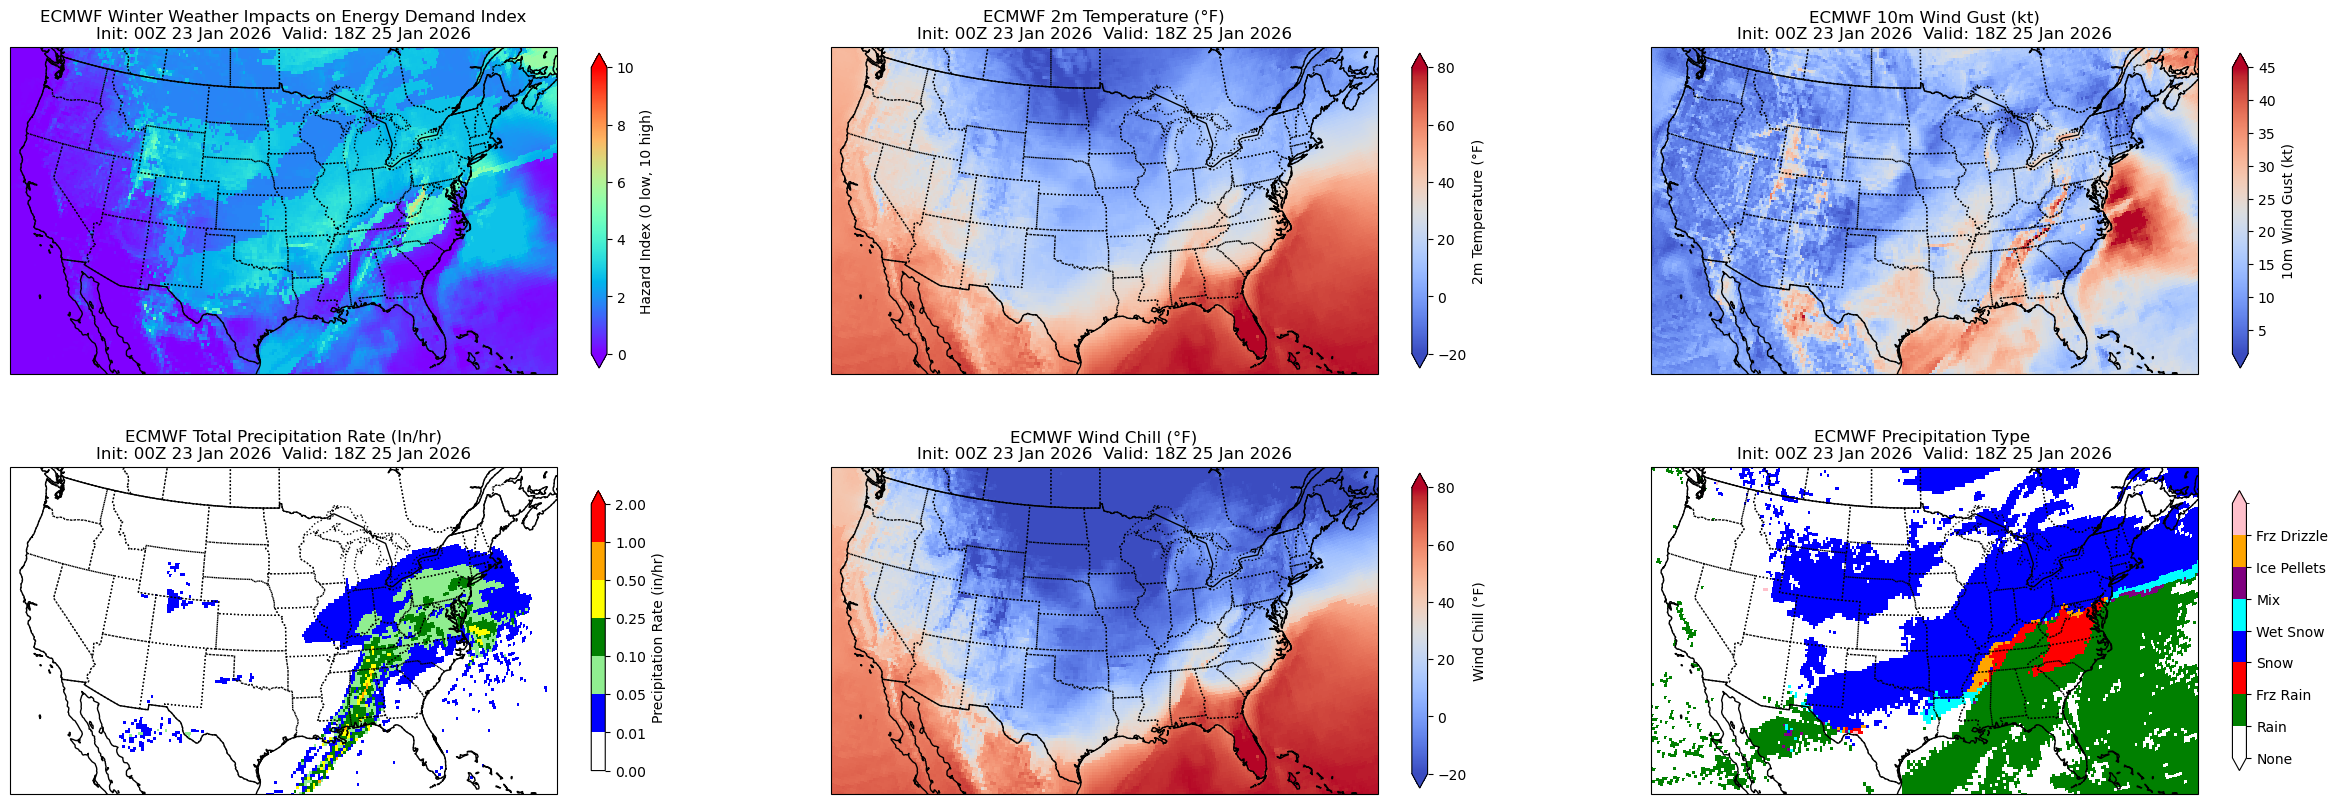

In [24]:
fig, axs = GeoAxes2d()

# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Timestep 5 (2026-01-24 06UTC) (MP)

In [25]:
time_index = 5
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 06Z 24 Jan 2026')

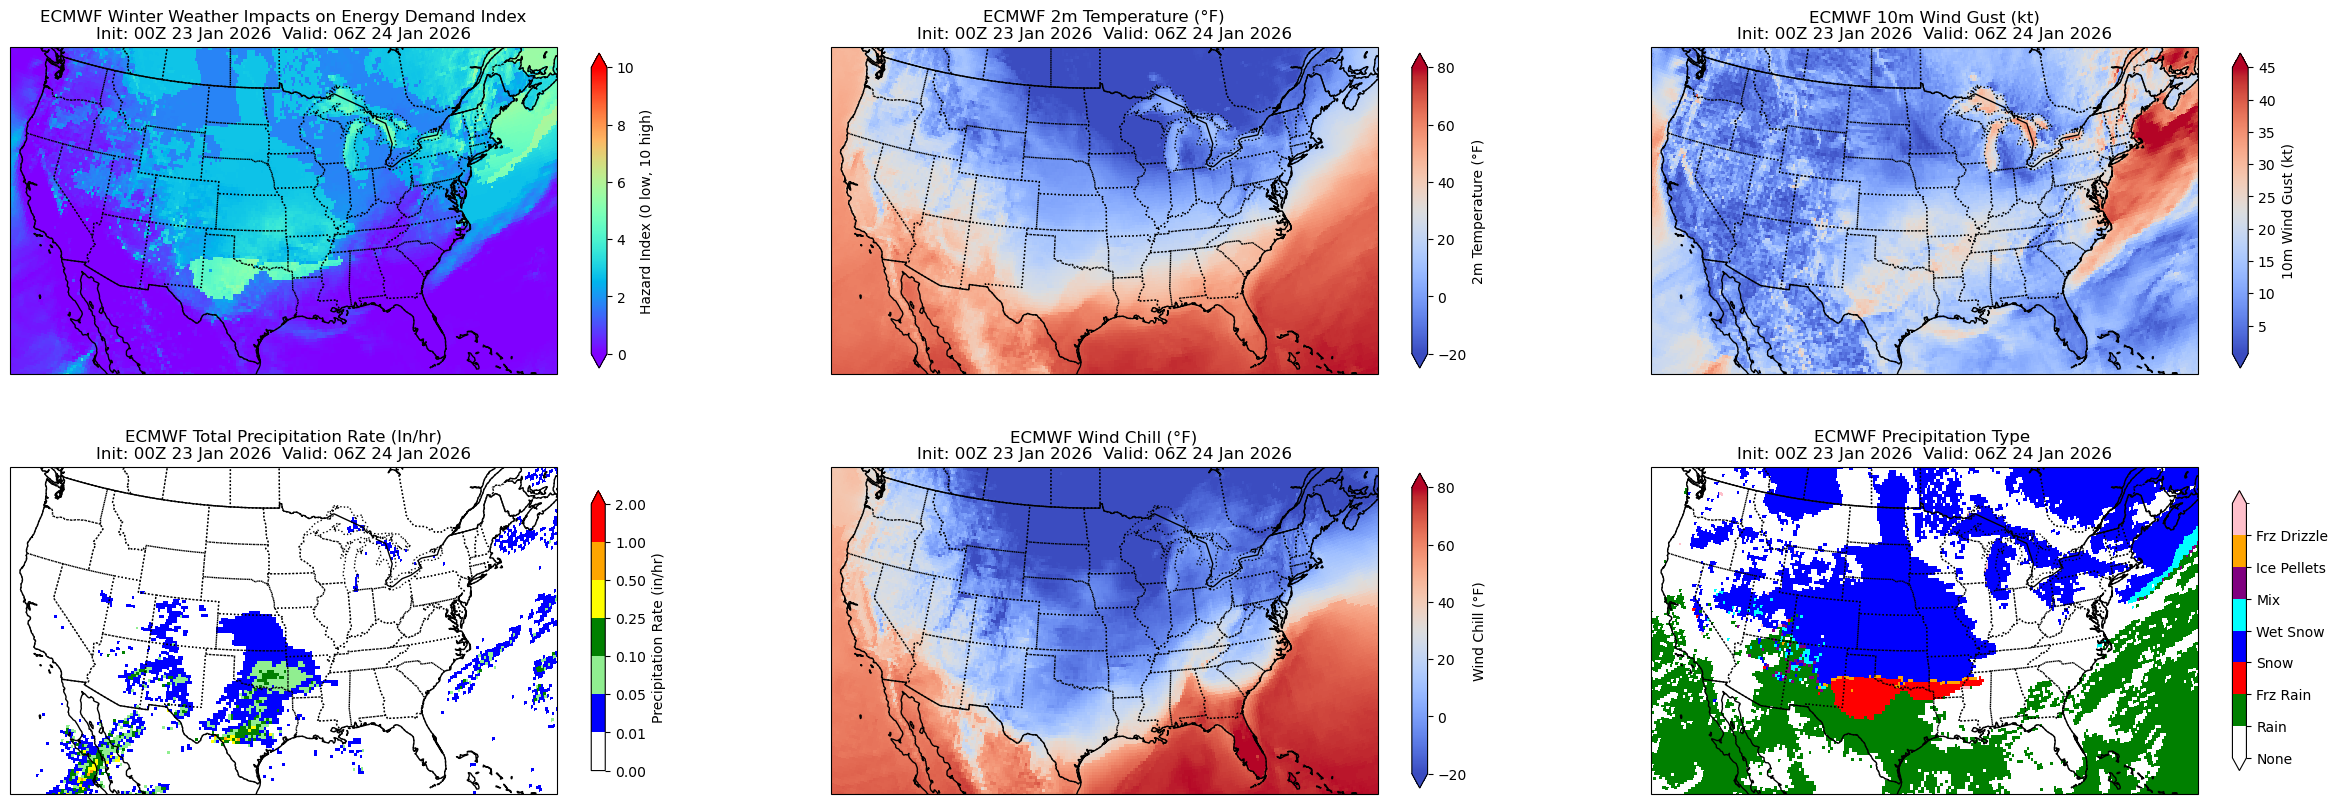

In [26]:
fig, axs = GeoAxes2d()
hazard_t0 = hazard[5]
# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Timestep 3 (2026-01-23 18 UTC) (MP)

In [27]:
time_index = 3
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 18Z 23 Jan 2026')

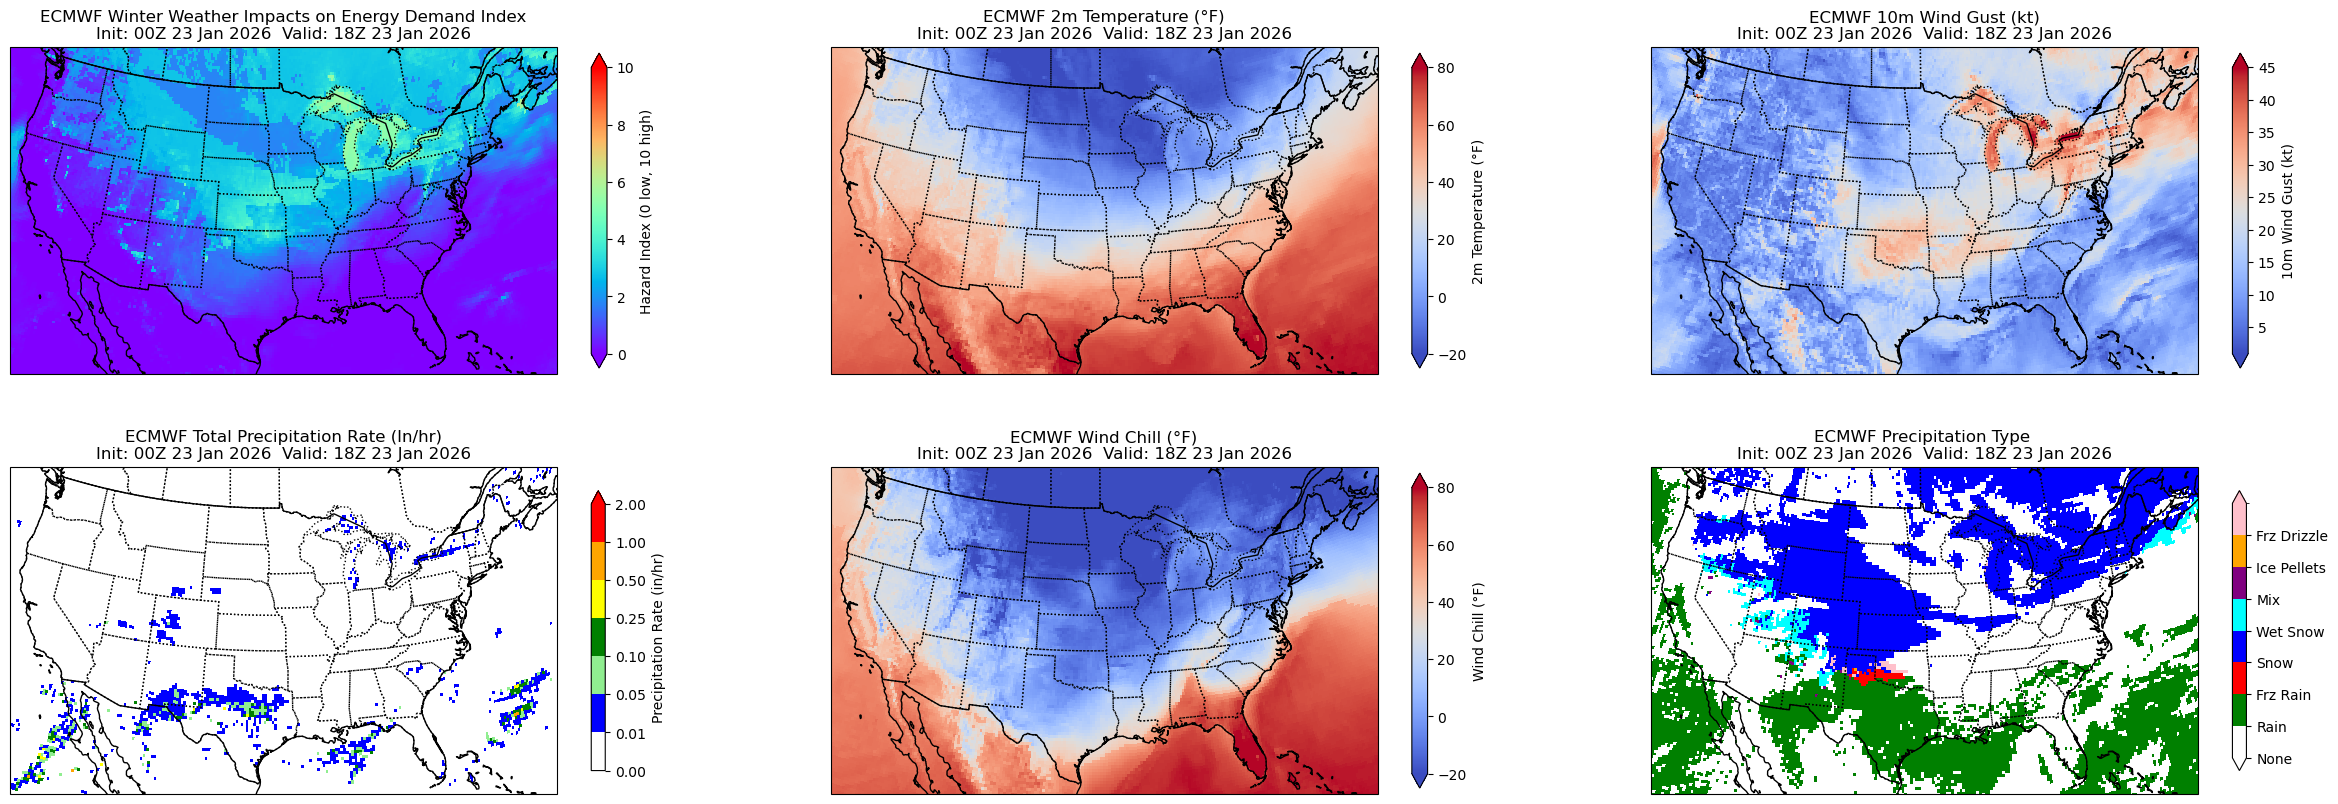

In [28]:
fig, axs = GeoAxes2d()
hazard_t0 = hazard[2]
# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Timestep 1 (2026-01-23 06 UTC) (MP)
- wind chill was not available at timestep 0, so had to choose 1

In [29]:
time_index = 1
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 06Z 23 Jan 2026')

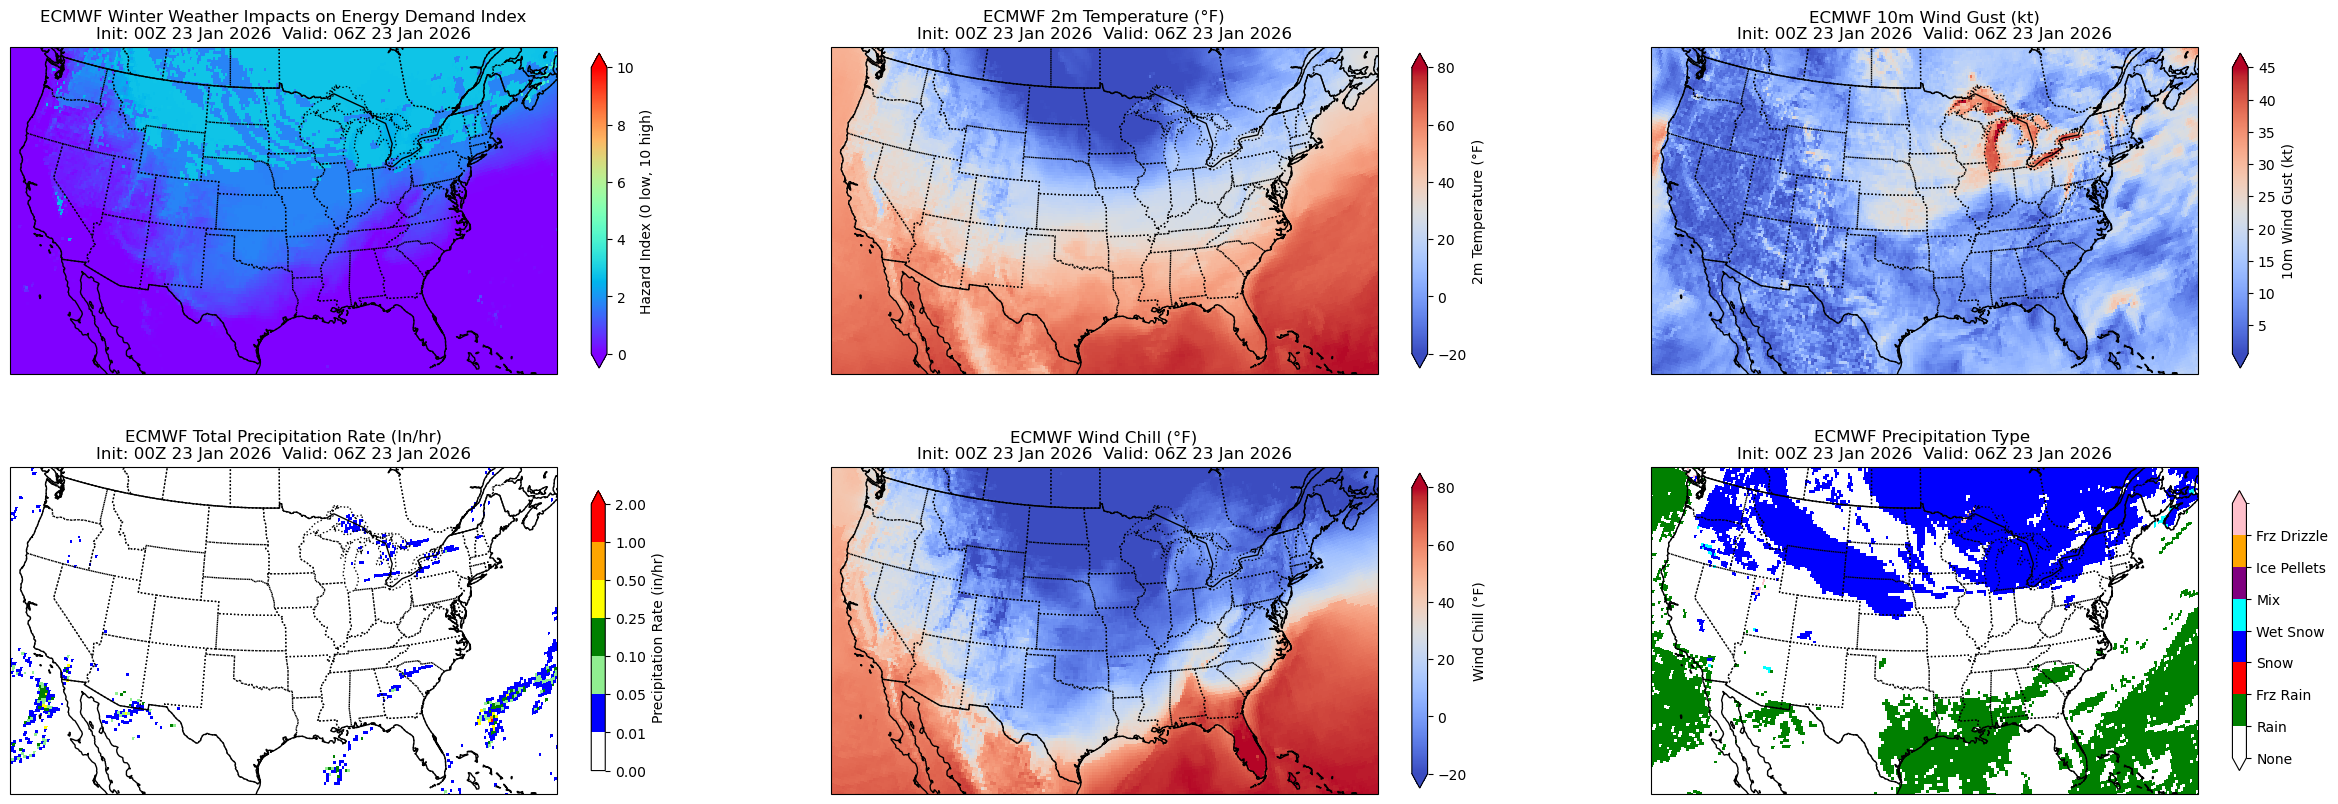

In [30]:
fig, axs = GeoAxes2d()
hazard_t0 = hazard[0]
# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Timestep 8 (2026-01-25 00UTC) (PD)

In [31]:
time_index = 8
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 00Z 25 Jan 2026')

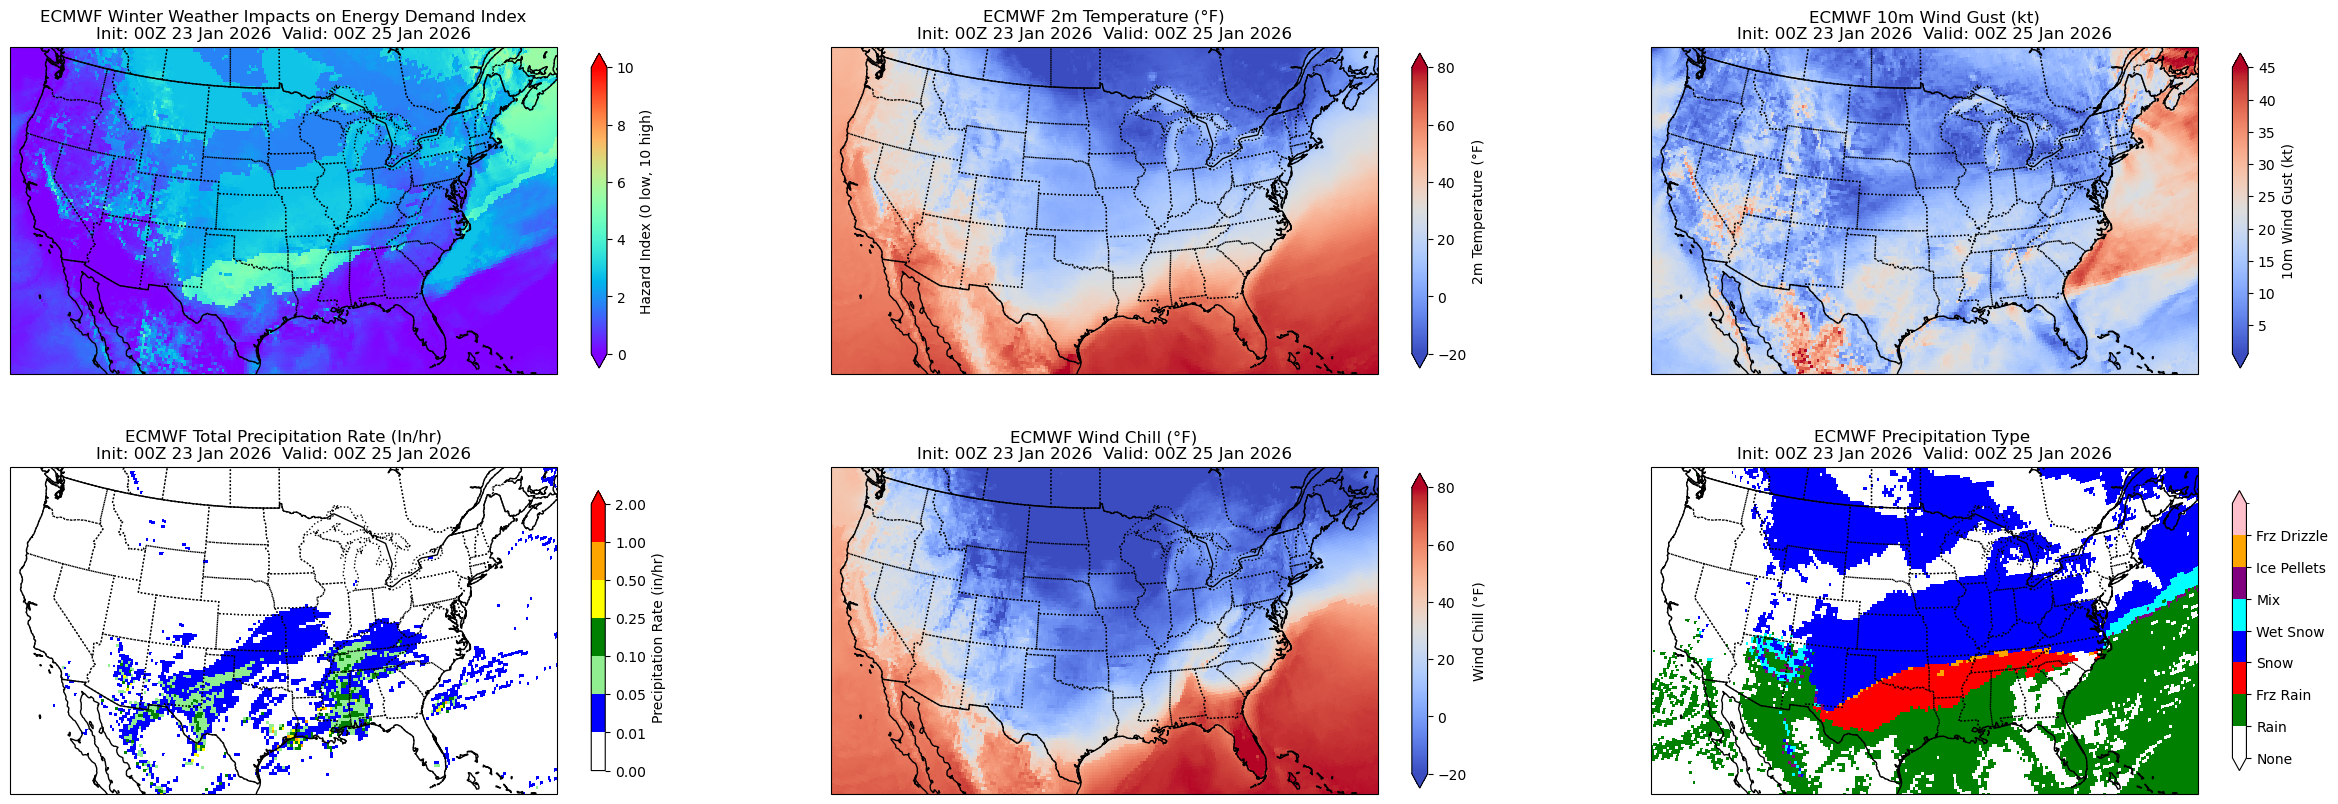

In [32]:
fig, axs = GeoAxes2d()
hazard_t0 = hazard[7]
# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Timestep 14 (2026-01-26 12UTC) (PD)

In [33]:
time_index = 14
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_test['t2m'].values
# defining lon/lat
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 12Z 26 Jan 2026')

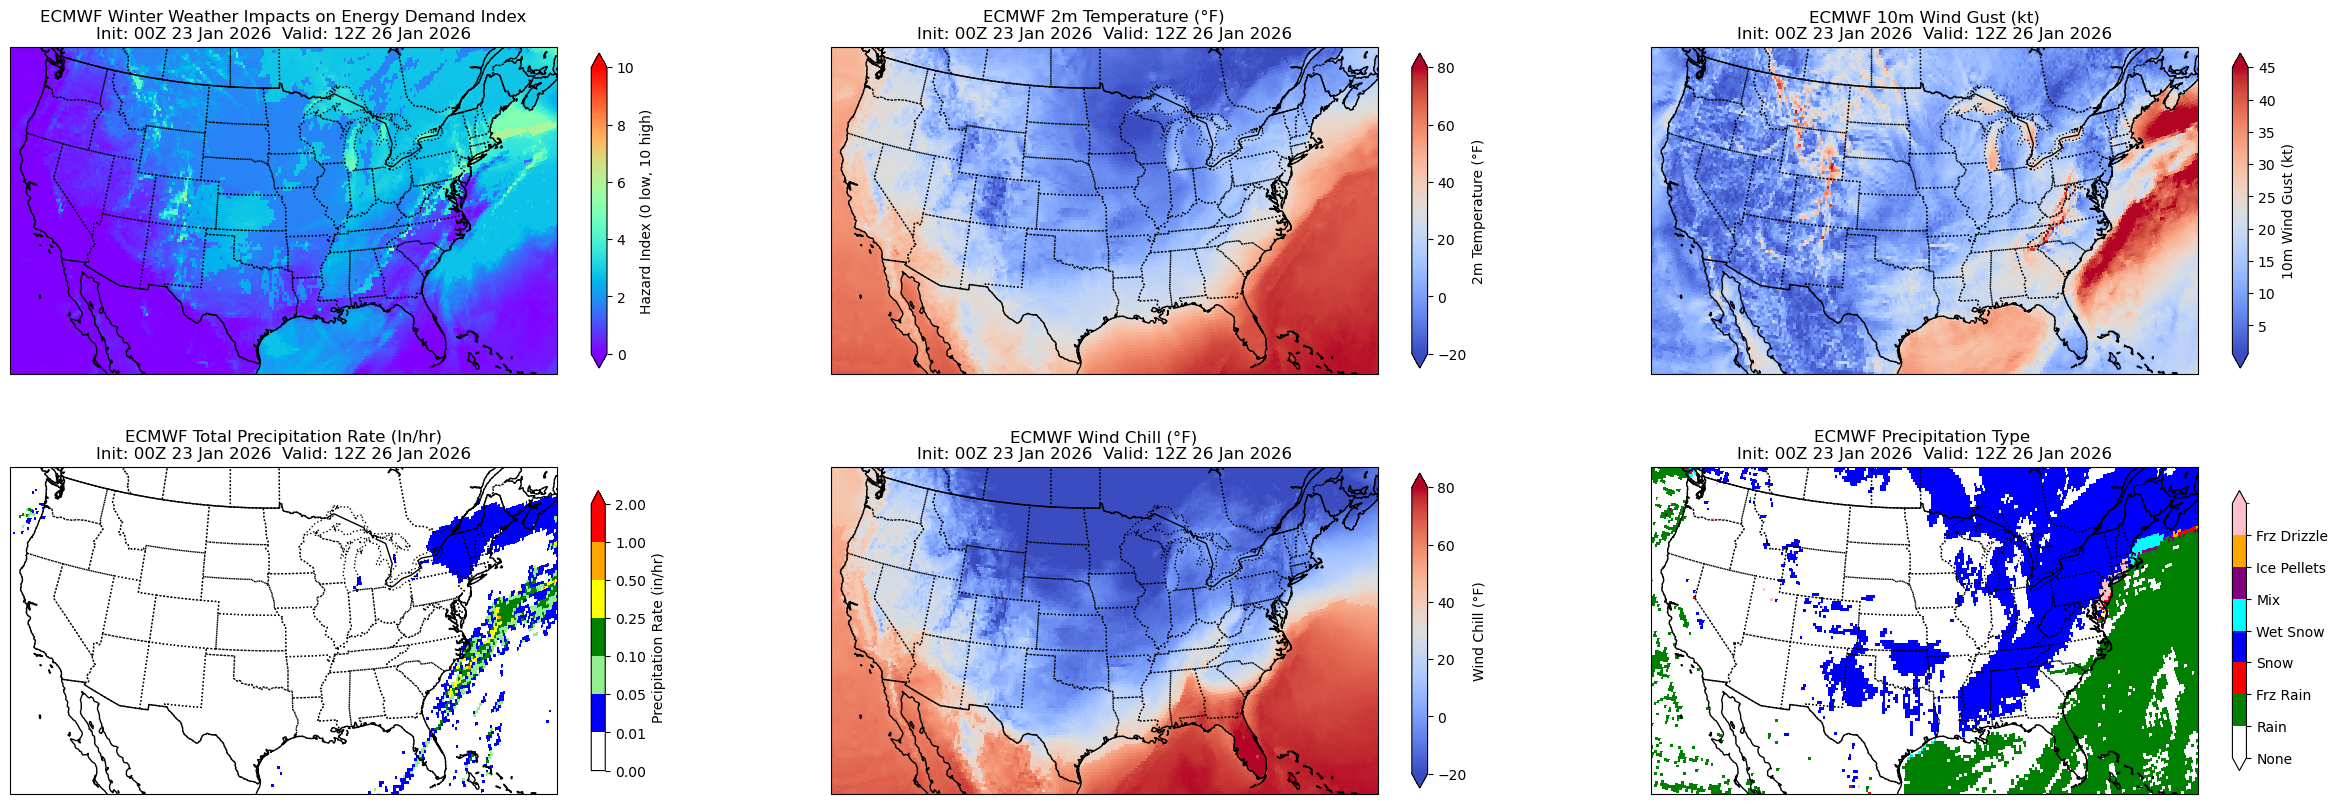

In [34]:
fig, axs = GeoAxes2d()
hazard_t0 = hazard[13]
# hazard index plot
mesh = axs[0,0].pcolormesh(lon, lat, hazard_t0, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.9)
axs[0,0].set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# 2m temp
t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = axs[0,1].pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, vmin = -20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.9)
axs[0,1].set_title(f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

# 10m wind gust
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = axs[0,2].pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.9)
axs[0,2].set_title(f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

# precip rate
bounds1 = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
colors1 = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors1)
norm = BoundaryNorm(bounds1, cmap.N)

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = axs[1,0].pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=axs[1,0], extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
axs[1,0].set_title(f"ECMWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# precip type
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = axs[1,2].pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=axs[1,2], extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
axs[1,2].set_title(f"ECMWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# wind chill
cs = axs[1,1].pcolormesh(lon, lat, wind_chill, transform=dataproj, vmin=-20, vmax = 80, cmap='coolwarm')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend = 'both', shrink=0.9)
axs[1,1].set_title(f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

# Additional Events (one high end one low end)

In [3]:
from herbie import Herbie, FastHerbie

## High End Case
- Blizzard of January 2018, Occured from Jan 3-4, 2018

## Low End Case
- Jan 17/18 2026, light snow across northeast region

In [4]:
# using code from milestone 1 to save new runs
run = pd.Timestamp("2026-01-17-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,54,6).tolist(), save_dir='./data/', overwrite=True)

In [5]:
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [6]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [7]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc892f9a__20260117000000-18h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc0e22e6__20260117000000-24h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bcef4d3c__20260117000000-0h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bcb2d9c9__20260117000000-6h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc60d181__20260117000000-30h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc1c22e6__20260117000000-48h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp2

In [8]:
ds = ds.sortby('valid_time')

In [9]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))

In [10]:
fname = f'ecmwf_low_end1.nc'
ds.to_netcdf(fname)

In [12]:
ds_low = xr.open_dataset("ecmwf_low_end1.nc").load()
ds_low

sh: 1: getfattr: not found


<xarray.Dataset> Size: 96MB
Dimensions:            (valid_time: 9, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-01-17 ... 2026-01-19
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-17
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 2MB 274.4 .....
    fg10               (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    tp                 (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    sd                 (valid_time, latitude, longitude) float32 2MB 0.1384 ....
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    ptype              (valid_time, latitude, longitude) float32 2MB 0.0 ... 0.0
    tprate             (valid_time, latitude, longitude) float32 2MB 0.0 ... 0.0
    sp                 (valid_time, latitude, longitude) float32 2MB 8.889e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T16:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
ds_low.valid_time

<xarray.DataArray 'valid_time' (valid_time: 9)> Size: 72B
array(['2026-01-17T00:00:00.000000000', '2026-01-17T06:00:00.000000000',
       '2026-01-17T12:00:00.000000000', '2026-01-17T18:00:00.000000000',
       '2026-01-18T00:00:00.000000000', '2026-01-18T06:00:00.000000000',
       '2026-01-18T12:00:00.000000000', '2026-01-18T18:00:00.000000000',
       '2026-01-19T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-01-17 ... 2026-01-19
    time               datetime64[ns] 8B 2026-01-17
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

In [14]:
time_index = 5
valid_time = ds_low.valid_time[time_index]
init_time = ds_low.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_low.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_low.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_low['t2m'].values
# defining lon/lat
# prelims
lat = ds_low.latitude.values
lon = ds_low.longitude.values
dataproj = ccrs.PlateCarree()

In [15]:
wind_gust = ds_low['fg10'].isel(valid_time=time_index).values
t2m = ds_low['t2m'].isel(valid_time=time_index).values
# converting t2m to F
t2m_F = (t2m - 273.15) * 9/5 + 32
# calculating total wind
#V_ms = np.sqrt(u_wind**2 + v_wind**2)
V_mph = wind_gust * 2.237
# applying WC formula
wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
# masking invalid conditions 
wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, t2m_F)

In [16]:
WC_contribution_l = np.clip(
    1.0
    - 0.1 * np.clip((wind_chill + 20) / 10, 0, 1)   # -20 → -10
    - 0.1 * np.clip((wind_chill + 10) / 10, 0, 1)   # -10 → 0
    - 0.3 * np.clip((wind_chill - 0) / 20, 0, 1)    # 0 → 20
    - 0.5 * np.clip((wind_chill - 20) / 20, 0, 1),  # 20 → 40
    0, 1
)
WC_contribution_low = WC_contribution_l*10

In [17]:
tprate_low = ds_low['tprate'].values
tprate_in = tprate_low*141.73

In [20]:
tprate_contribution_l = np.clip(
    0.0
    +0.2 * np.clip((tprate_in - 0.1) / 0.2, 0, 1)
    +0.4 * np.clip((tprate_in - 0.3) / 0.3, 0, 1)
    +0.2 * np.clip((tprate_in - 0.5) / 0.2, 0, 1)
    +0.2 * np.clip((tprate_in - 0.8) / 0.2, 0, 1),
    0, 1
)
tprate_contribution_low = tprate_contribution_l*10

In [22]:
ptype_low = ds_low['ptype'].values
ptype_scale = {
    0: 0,  # None
    1: 1,  # Rain
    7: 2,  # Rain/snow mix
    8: 3,  # Ice pellets
    5: 4,  # Snow
    12: 5, # Freezing drizzle
    6: 6,  # Wet snow
    3: 7   # Freezing rain
}
ptype_rank_low = np.vectorize(ptype_scale.get)(ptype_low)

In [25]:
ptype_contribution_l = np.clip(
    0.0
    + 0.25 * np.clip((ptype_rank_low - 1) / 2, 0, 1)   # Rain → Mix
    + 0.25 * np.clip((ptype_rank_low - 3) / 2, 0, 1)   # Ice → Snow
    + 0.25 * np.clip((ptype_rank_low - 5) / 1, 0, 1)   # FZDZ → Wet snow
    + 0.25 * np.clip((ptype_rank_low - 6) / 1, 0, 1),  # Wet snow → FZRA
    0, 1
)
ptype_contribution_low = ptype_contribution_l*10

In [27]:
# wind gust
wgust_low = ds_low['fg10'] * 1.94384449

# initialize
wind_hazard_low = xr.zeros_like(wgust_low)

# middle range: 10–35 kt
mask_mid = (wgust_low >= 10) & (wgust_low <= 35)
wind_hazard_low = wind_hazard_low.where(
    ~mask_mid,
    10 * ((wgust_low - 10) / 25.0) ** 2
)

# above 35 kt → cap at 10
wind_hazard_low = wind_hazard_low.where(wgust_low <= 35, 10)

In [29]:
# 2m temp
temp_index_low = 10 * ((40 - t2m_F) / 30)

# Apply bounds
temp_index_low = temp_index_low.clip(min=0, max=10)

In [30]:
def overall_index(temp_index_low, wind_hazard_low, WC_contribution_low, ptype_contribution_low, tprate_contribution_low):
    return (temp_index_low*0.15 + wind_hazard_low*0.275 + WC_contribution_low*0.275 + tprate_contribution_low*0.025 + ptype_contribution_low*0.275)
hazard_l = overall_index(temp_index_low, wind_hazard_low, ptype_contribution_low, tprate_contribution_low, WC_contribution_low)
hazard_low = hazard_l[5]

Text(0.5, 1.0, 'Hazard Index \nInit: 00Z 17 Jan 2026  Valid: 06Z 18 Jan 2026')

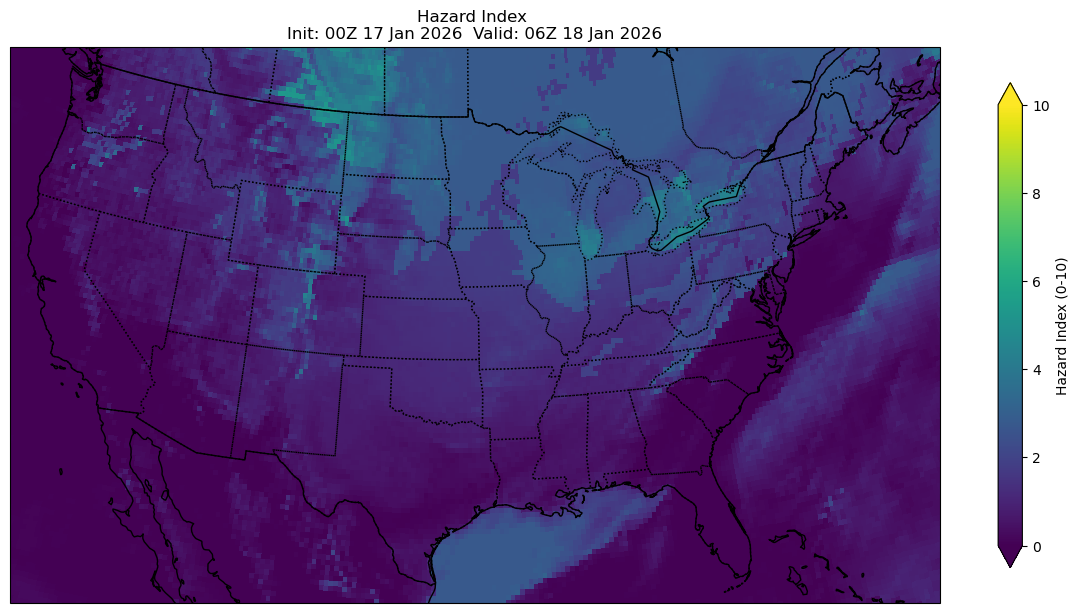

In [35]:
fig, ax = GeoAxes()

cs = ax.pcolormesh(lon, lat, hazard_low, transform=dataproj, vmin=0, vmax=10)
plt.colorbar(cs, label = 'Hazard Index (0-10)', extend = 'both', shrink=0.7)
ax.set_title(f"Hazard Index \nInit: {init_str}  Valid: {valid_str}")

## high end

In [57]:
# using code from milestone 1 to save new runs
run = pd.Timestamp("2026-2-22-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,54,6).tolist(), save_dir='./data/', overwrite=True)

In [58]:
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [59]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [60]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

/tmp/ipykernel_599959/2824649474.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
/tmp/ipykernel_599959/2824649474.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')


In [61]:
ds = ds.sortby('valid_time')

In [62]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))

In [63]:
fname = f'ecmwf_high_end2.nc'
ds.to_netcdf(fname)

In [64]:
ds_high = xr.open_dataset("ecmwf_high_end2.nc").load()
ds_high

sh: 1: getfattr: not found


<xarray.Dataset> Size: 96MB
Dimensions:            (valid_time: 9, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-02-22 ... 2026-02-24
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-02-22
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 2MB 249.9 .....
    fg10               (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    sd                 (valid_time, latitude, longitude) float32 2MB 0.1794 ....
    tp                 (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    ptype              (valid_time, latitude, longitude) float32 2MB 5.0 ... 0.0
    tprate             (valid_time, latitude, longitude) float32 2MB 5.245e-0...
    sp                 (valid_time, latitude, longitude) float32 2MB 8.979e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T17:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [65]:
ds_high.valid_time

<xarray.DataArray 'valid_time' (valid_time: 9)> Size: 72B
array(['2026-02-22T00:00:00.000000000', '2026-02-22T06:00:00.000000000',
       '2026-02-22T12:00:00.000000000', '2026-02-22T18:00:00.000000000',
       '2026-02-23T00:00:00.000000000', '2026-02-23T06:00:00.000000000',
       '2026-02-23T12:00:00.000000000', '2026-02-23T18:00:00.000000000',
       '2026-02-24T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-02-22 ... 2026-02-24
    time               datetime64[ns] 8B 2026-02-22
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

In [115]:
time_index = 5
valid_time = ds_high.valid_time[time_index]
init_time = ds_high.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_high.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_high.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")
# defining t2m again
t2m = ds_high['t2m'].values
# defining lon/lat
# prelims
lat = ds_high.latitude.values
lon = ds_high.longitude.values
dataproj = ccrs.PlateCarree()

In [116]:
wind_gust = ds_high['fg10'].isel(valid_time=time_index).values
t2m = ds_high['t2m'].isel(valid_time=time_index).values
# converting t2m to F
t2m_F = (t2m - 273.15) * 9/5 + 32
# calculating total wind
#V_ms = np.sqrt(u_wind**2 + v_wind**2)
V_mph = wind_gust * 2.237
# applying WC formula
wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
# masking invalid conditions 
wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, t2m_F)

In [117]:
WC_contribution_h = np.clip(
    1.0
    - 0.1 * np.clip((wind_chill + 20) / 10, 0, 1)   # -20 → -10
    - 0.1 * np.clip((wind_chill + 10) / 10, 0, 1)   # -10 → 0
    - 0.3 * np.clip((wind_chill - 0) / 20, 0, 1)    # 0 → 20
    - 0.5 * np.clip((wind_chill - 20) / 20, 0, 1),  # 20 → 40
    0, 1
)
WC_contribution_high = WC_contribution_h*10

In [118]:
tprate_high = ds_high['tprate'].values
tprate_in = tprate_high*141.73

In [119]:
tprate_contribution_h = np.clip(
    0.0
    +0.2 * np.clip((tprate_in - 0.1) / 0.2, 0, 1)
    +0.4 * np.clip((tprate_in - 0.3) / 0.3, 0, 1)
    +0.2 * np.clip((tprate_in - 0.5) / 0.2, 0, 1)
    +0.2 * np.clip((tprate_in - 0.8) / 0.2, 0, 1),
    0, 1
)
tprate_contribution_high = tprate_contribution_h*10

In [120]:
ptype_high = ds_high['ptype'].values
ptype_scale = {
    0: 0,  # None
    1: 1,  # Rain
    7: 2,  # Rain/snow mix
    8: 3,  # Ice pellets
    5: 4,  # Snow
    12: 5, # Freezing drizzle
    6: 6,  # Wet snow
    3: 7   # Freezing rain
}
ptype_rank_high = np.vectorize(ptype_scale.get)(ptype_high)

In [121]:
ptype_contribution_h = np.clip(
    0.0
    + 0.25 * np.clip((ptype_rank_high - 1) / 2, 0, 1)   # Rain → Mix
    + 0.25 * np.clip((ptype_rank_high - 3) / 2, 0, 1)   # Ice → Snow
    + 0.25 * np.clip((ptype_rank_high - 5) / 1, 0, 1)   # FZDZ → Wet snow
    + 0.25 * np.clip((ptype_rank_high - 6) / 1, 0, 1),  # Wet snow → FZRA
    0, 1
)
ptype_contribution_high = ptype_contribution_h*10

In [122]:
# wind gust
wgust_high = ds_high['fg10'] * 1.94384449

# initialize
wind_hazard_high = xr.zeros_like(wgust_high)

# middle range: 10–35 kt
mask_mid = (wgust_high >= 10) & (wgust_high <= 35)
wind_hazard_high = wind_hazard_high.where(
    ~mask_mid,
    10 * ((wgust_high - 10) / 25.0) ** 2
)

# above 35 kt → cap at 10
wind_hazard_high = wind_hazard_high.where(wgust_high <= 35, 10)

In [123]:
# 2m temp
temp_index_high = 10 * ((40 - t2m_F) / 30)

# Apply bounds
temp_index_high = temp_index_high.clip(min=0, max=10)

In [124]:
def overall_index(temp_index_high, wind_hazard_high, WC_contribution_high, ptype_contribution_high, tprate_contribution_high):
    return (temp_index_high*0.15 + wind_hazard_high*0.275 + WC_contribution_high*0.275 + tprate_contribution_high*0.025 + ptype_contribution_high*0.275)
hazard_h = overall_index(temp_index_high, wind_hazard_high, ptype_contribution_high, tprate_contribution_high, WC_contribution_high)
hazard_high = hazard_h[5]

Text(0.5, 1.0, 'Hazard Index \nInit: 00Z 22 Feb 2026  Valid: 06Z 23 Feb 2026')

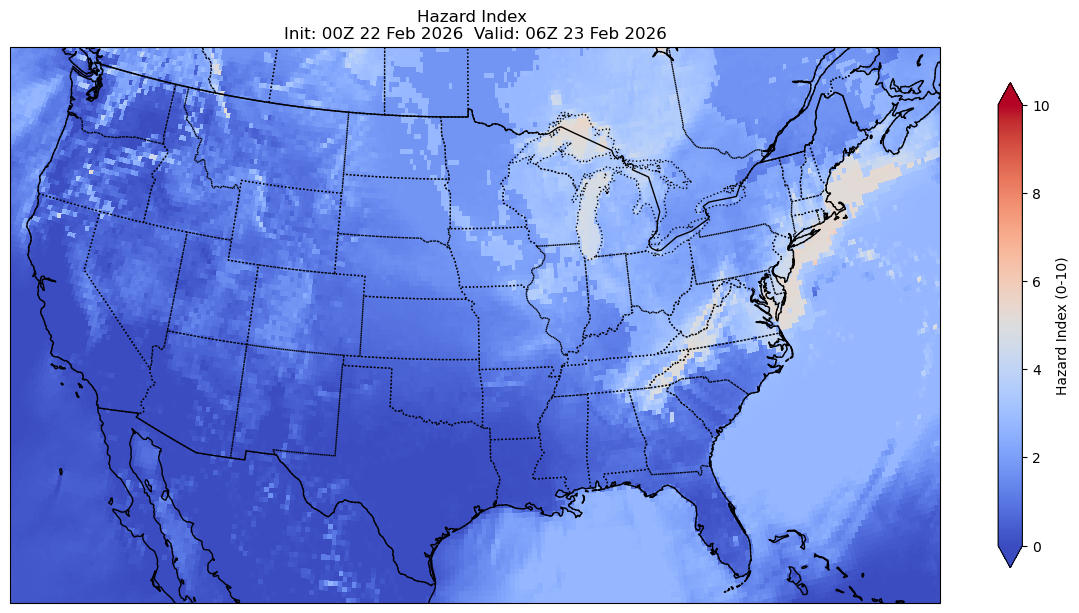

In [125]:
fig, ax = GeoAxes()

cs = ax.pcolormesh(lon, lat, hazard_high, transform=dataproj, vmin=0, vmax=10, cmap='coolwarm')
plt.colorbar(cs, label = 'Hazard Index (0-10)', extend = 'both', shrink=0.7)
ax.set_title(f"Hazard Index \nInit: {init_str}  Valid: {valid_str}")

## Performance
- Maximum and minimum values make sense on both plots with it being consistent with our first data download
- The only problem is these values not reaching the theoretical max of 10, but these values are only for worst case scenarios
- There doesn't seem to be false alarms, most slightly increased areas are due to high wind gusts which can still cause problems either way for energy demand
- We didn't make any changes to the index as we thought that these values were significant enough in our index